In [1]:
import os
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

os.chdir('/home/onyxia/work/bdc-apicil-g1')

from src.model import FEATURES, TARGET, split_data, train_model, evaluate, save_model

In [2]:
df = pd.read_csv('data/processed/panel_final.csv')

/tmp/ipykernel_31459/3603614529.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/processed/panel_final.csv')


In [4]:
x_train, x_test, y_train, y_test = split_data(df)

Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)


In [5]:
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
    ))
])

model = train_model(model, x_train, y_train)

Entraînement de Pipeline...
Entraînement terminé.



Modèle : Pipeline
AUC-ROC   : 0.3803  — aire sous la courbe ROC
AUC-PR    : 0.0136  — aire sous la courbe Précision-Recall (plus fiable avec classes déséquilibrées)
Recall    : 0.0000  — taux de résiliants détectés
Précision : 0.0000  — part de vrais résiliants parmi les alertes
F1        : 0.0000  — équilibre recall/précision
F2        : 0.0000  — pénalise davantage les faux négatifs
MCC       : 0.0000  — robuste au déséquilibre des classes
Brier     : 0.0175  — calibration des probabilités (plus bas = mieux)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    375637
           1       0.00      0.00      0.00      6706

    accuracy                           0.98    382343
   macro avg       0.49      0.50      0.50    382343
weighted avg       0.97      0.98      0.97    382343



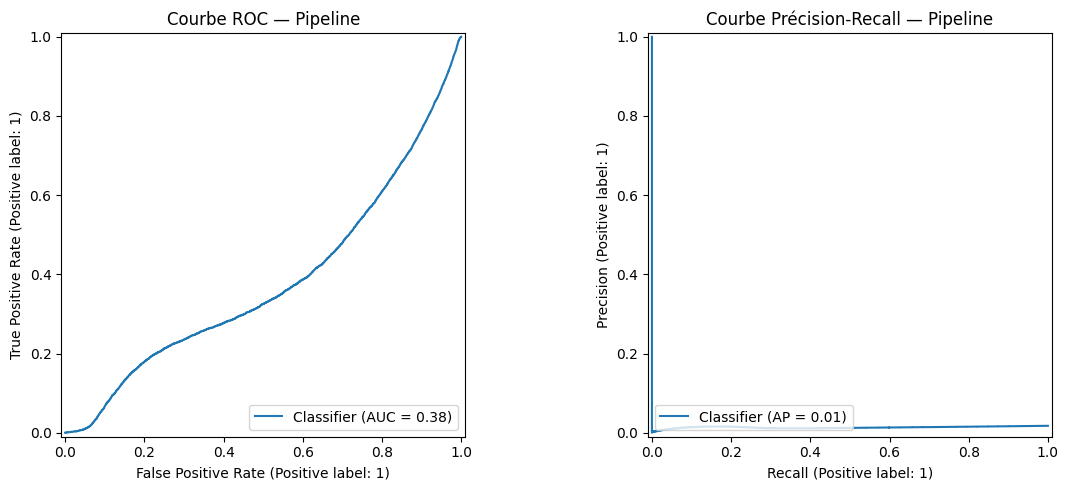

In [6]:
metrics = evaluate(model, x_test, y_test)

In [7]:
save_model(model, 'logistic_regression_insee')

Modèle sauvegardé dans models/logistic_regression_insee.pkl


'models/logistic_regression_insee.pkl'